In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("IPL_Dataset.csv")
df.sample()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
43,44,Pat Cummins,14,11,4,146,53*,20.85,114,128.07,0,1,9,8


Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [73]:
max_matches = df['Matches'].max()
player_max_matches = df[df['Matches'] == max_matches][['Player', 'Matches']]
print("Maximum matches played:\n\n", player_max_matches)

Maximum matches played:

             Player  Matches
1   Shikhar Dhawan       17
3     Shreyas Iyer       17
19  Marcus Stoinis       17
67   Kagiso Rabada       17


Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [46]:
top_players = df[(df['50'] >= 2)].nlargest(2, 'Avg')[['Player', 'Avg']]
print(top_players)

             Player    Avg
36  Wriddhiman Saha  71.33
4      Ishan Kishan  57.33


Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [61]:
df[['First Name', 'Last Name']] = df['Player'].str.split(' ', n=1, expand=True)
print(df[['Player', 'First Name', 'Last Name']].head())

           Player First Name Last Name
0        KL Rahul         KL     Rahul
1  Shikhar Dhawan    Shikhar    Dhawan
2    David Warner      David    Warner
3    Shreyas Iyer    Shreyas      Iyer
4    Ishan Kishan      Ishan    Kishan


Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [64]:
df['Cleaned_Highest_score'] = df['Highest Score'].str.replace('*', '').astype(int)
print(df[['Highest Score', 'Cleaned_Highest_score']].head())

  Highest Score  Cleaned_Highest_score
0          132*                    132
1          106*                    106
2           85*                     85
3           88*                     88
4            99                     99


Q5. Print the total number of centuries scored in the entire season.

In [67]:
total_centuries = df['100'].sum()
print(f"Total centuries: {total_centuries}")

Total centuries: 5


In [75]:
avg_strike_rate = df['Strike rate'].mean()
low_strike_rate_players = df[df['Strike rate'] < avg_strike_rate][['Player', 'Strike rate']]
low_strike_rate_players['Average Strike Rate'] = avg_strike_rate
print(low_strike_rate_players)

                  Player  Strike rate  Average Strike Rate
51        Ajinkya Rahane       105.60           107.364737
55         Glenn Maxwell       101.88           107.364737
58         Vijay Shankar       101.04           107.364737
61         Josh Philippe       101.29           107.364737
62       Gurkeerat Singh        88.75           107.364737
65          Kedar Jadhav        93.93           107.364737
70      Yashasvi Jaiswal        90.90           107.364737
71         Shreyas Gopal        94.87           107.364737
77          Murali Vijay        74.41           107.364737
79          Chris Jordan        93.54           107.364737
80         Navdeep Saini       100.00           107.364737
82     Kamlesh Nagarkoti        70.96           107.364737
84         Harshal Patel        87.50           107.364737
85         Jimmy Neesham       105.55           107.364737
86            Tom Banton        90.00           107.364737
89     Prabhsimran Singh       100.00           107.3647

Q7. Please check the correlation between the features and create a heat map.

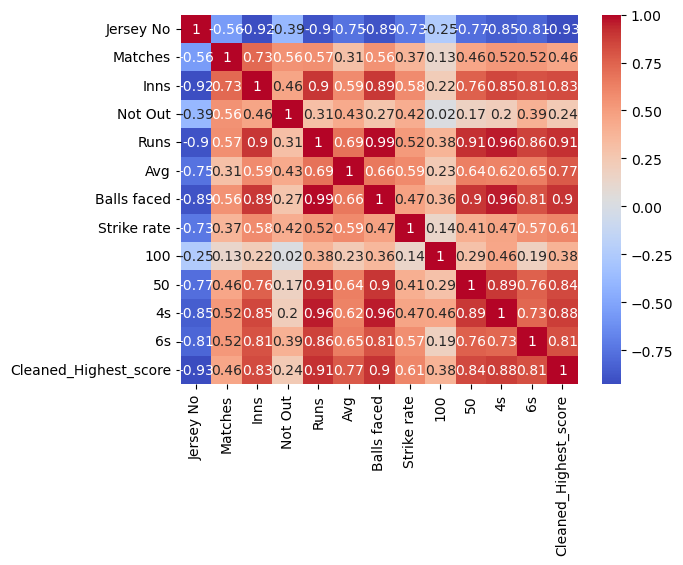

In [82]:
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [85]:
high_avg_strike_rate = df[(df['Avg'] > 50) & (df['Strike rate'] > 120)][['Player', 'Avg', 'Strike rate']]
print(high_avg_strike_rate)

             Player     Avg  Strike rate
0          KL Rahul   55.83       129.34
4      Ishan Kishan   57.33       145.76
31   Kieron Pollard   53.60       191.42
36  Wriddhiman Saha   71.33       139.86
37  Ruturaj Gaikwad   51.00       120.71
57     Deepak Hooda  101.00       142.25
60       Tom Curran   83.00       133.87


Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [88]:
high_avg_balls_faced = df[(df['Avg'] > 40) & (df['Balls faced'] > 100)][['Player', 'Avg', 'Balls faced']]
print(high_avg_balls_faced)

             Player    Avg  Balls faced
0          KL Rahul  55.83          518
1    Shikhar Dhawan  44.14          427
4      Ishan Kishan  57.33          354
8       Virat Kohli  42.36          384
9      ABD Villiers  45.40          286
10    Faf Duplessis  40.81          319
14      Eoin Morgan  41.80          302
24  Kane Williamson  45.28          237
27      Chris Gayle  41.14          210
28       Ben Stokes  40.71          200
31   Kieron Pollard  53.60          140
32    Rahul Tewatia  42.50          183
33  Ravindra Jadeja  46.40          135
36  Wriddhiman Saha  71.33          153
37  Ruturaj Gaikwad  51.00          169


Q10. Players who scored atleast one century in this season. Create visualization.

Century Players
             Player  100
0         KL Rahul    1
1   Shikhar Dhawan    2
13  Mayank Agarwal    1
28      Ben Stokes    1


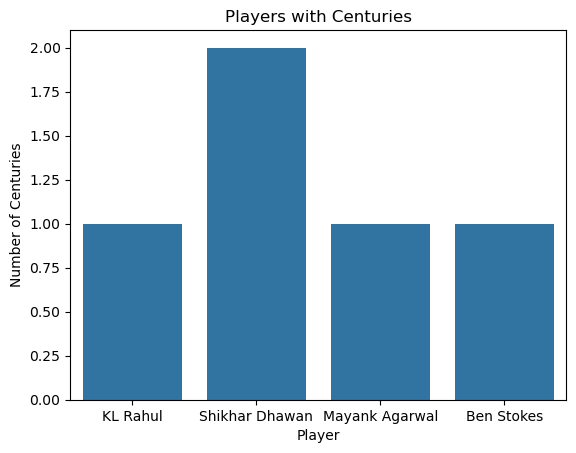

In [123]:
century_players = df[df['100'] >= 1][['Player', '100']]
print(f"Century Players\n {century_players}")

sns.barplot(data=df[df['100'] >= 1], x='Player', y='100', estimator=sum)
plt.title("Players with Centuries")
plt.ylabel("Number of Centuries")
plt.show()

Q11. Players who scored atleast 4 half centuries in this season.

In [128]:
half_century_players = df[df['50'] >= 4][['Player', '50']]
print(half_century_players)

              Player  50
0           KL Rahul   5
1     Shikhar Dhawan   4
2       David Warner   4
4       Ishan Kishan   4
5       Quinton Kock   4
6   Suryakumar Yadav   4
7   Devdutt Padikkal   5
9       ABD Villiers   5
10     Faf Duplessis   4


Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [135]:
boundary_players = df[(df['4s'] > 45) & (df['6s'] > 10)][['Player','4s','6s']]
print(boundary_players)

             Player  4s  6s
0          KL Rahul  58  23
1    Shikhar Dhawan  67  12
2      David Warner  52  14
5      Quinton Kock  46  22
6  Suryakumar Yadav  61  11


Q13. Plot a histogram of number of matches played in a season by players.

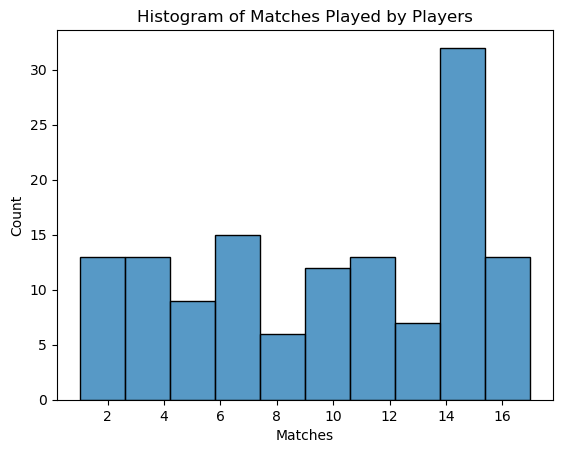

In [140]:
sns.histplot(df['Matches'], bins=10)
plt.title("Histogram of Matches Played by Players")
plt.show()

Q14. Plot the histogram of balls faced by players.

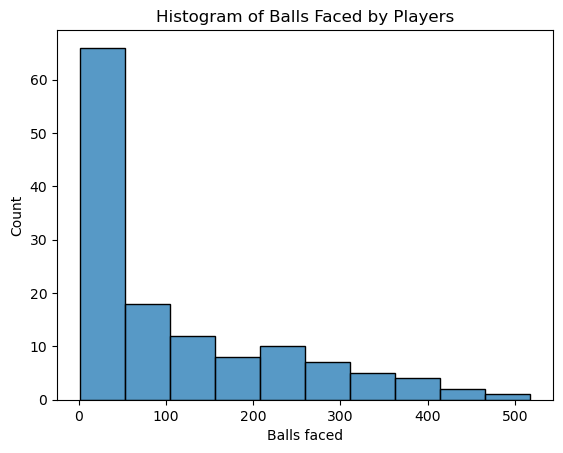

In [145]:
sns.histplot(df['Balls faced'], bins=10)
plt.title("Histogram of Balls Faced by Players")
plt.show()

Q15. Top 10 players with most runs in a season.

In [148]:
top_runs_players = df.nlargest(10, 'Runs')[['Player', 'Runs']]
print(top_runs_players)

             Player  Runs
0          KL Rahul   670
1    Shikhar Dhawan   618
2      David Warner   548
3      Shreyas Iyer   519
4      Ishan Kishan   516
5      Quinton Kock   503
6  Suryakumar Yadav   480
7  Devdutt Padikkal   473
8       Virat Kohli   466
9      ABD Villiers   454


Q16. Print the players who played the match but didn't get the batting.

In [151]:
no_batting_players = df[df['Inns'] == 0]['Player']
print(no_batting_players)

Series([], Name: Player, dtype: object)


Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [155]:
df['Boundary_Runs'] = (df['4s'] * 4) + (df['6s'] * 6)
df['Boundary_Run_Percentage'] = (df['Boundary_Runs'] / df['Runs']) * 100
top_boundary_players = df.nlargest(5, 'Boundary_Run_Percentage')[['Player', 'Boundary_Run_Percentage']]
print(top_boundary_players)

            Player  Boundary_Run_Percentage
109     Andrew Tye               100.000000
48   Andre Russell                76.923077
74    Chris Morris                76.470588
29   Hardik Pandya                73.309609
47    Sunil Narine                72.727273


Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [158]:
df['Not_Out_Percentage'] = (df['Not Out'] / df['Inns']) * 100
top_not_out_players = df.nlargest(5, 'Not_Out_Percentage')[['Player', 'Not_Out_Percentage']]
print(top_not_out_players)

              Player  Not_Out_Percentage
62   Gurkeerat Singh               100.0
68   Lockie Ferguson               100.0
93       Imran Tahir               100.0
97     Mohammad Nabi               100.0
105     Pravin Dubey               100.0


Q19. Create visualization of top 10 players with highest number of sixes.

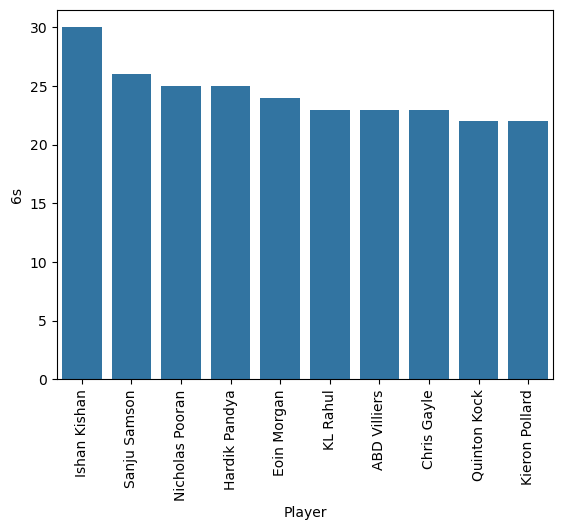

In [163]:
top_six_players = df.nlargest(10, '6s')[['Player', '6s']]
sns.barplot(data=top_six_players, x='Player', y='6s')
plt.xticks(rotation=90)
plt.show()

Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

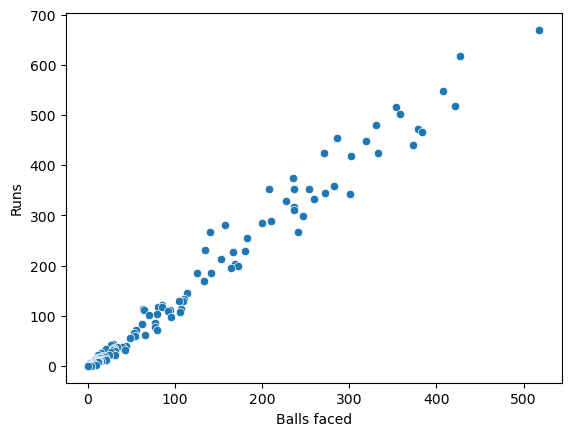

Correlation between Runs and Balls Faced: 0.9899480233860845


In [166]:
sns.scatterplot(data=df, x='Balls faced', y='Runs')
plt.show()

correlation = df['Runs'].corr(df['Balls faced'])
print(f"Correlation between Runs and Balls Faced: {correlation}")